# Random Forest Classification

---

**Name:** Shruti Hore  

**PRN:** 24070126172  

## Import libraries and load dataset

In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [15]:
df = pd.read_csv("(RF) full_data.csv")
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [16]:
print("Shape : ", df.shape)

Shape :  (4981, 11)


In [17]:
print("Data Info : \n", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   object 
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   object 
 5   work_type          4981 non-null   object 
 6   Residence_type     4981 non-null   object 
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   object 
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 428.2+ KB
Data Info : 
 None


In [18]:
print("Statistical Description : \n", df.describe())

Statistical Description : 
                age  hypertension  heart_disease  avg_glucose_level  \
count  4981.000000   4981.000000    4981.000000        4981.000000   
mean     43.419859      0.096165       0.055210         105.943562   
std      22.662755      0.294848       0.228412          45.075373   
min       0.080000      0.000000       0.000000          55.120000   
25%      25.000000      0.000000       0.000000          77.230000   
50%      45.000000      0.000000       0.000000          91.850000   
75%      61.000000      0.000000       0.000000         113.860000   
max      82.000000      1.000000       1.000000         271.740000   

               bmi       stroke  
count  4981.000000  4981.000000  
mean     28.498173     0.049789  
std       6.790464     0.217531  
min      14.000000     0.000000  
25%      23.700000     0.000000  
50%      28.100000     0.000000  
75%      32.600000     0.000000  
max      48.900000     1.000000  


In [19]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

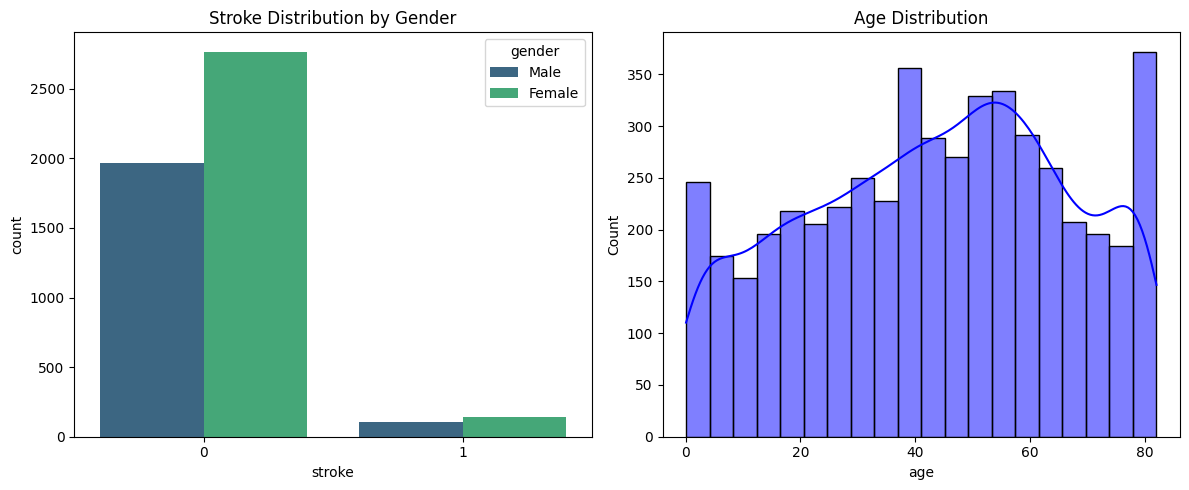

In [20]:
# EDA Visualizations
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='stroke', hue='gender', palette='viridis')
plt.title('Stroke Distribution by Gender')

plt.subplot(1, 2, 2)
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Age Distribution')
plt.tight_layout()

In [21]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

In [22]:
# encode categorical data
LE = LabelEncoder()
cat = ['gender', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status']
for col in cat:
    df[col] = LE.fit_transform(df[col])

In [23]:
# feature selection
X = df.drop('stroke', axis=1)
y = df['stroke']

## 60-40 Splitting

In [36]:
X_tr60, X_te40, y_tr60, y_te40 = train_test_split(X, y,
                                                  test_size=0.4,
                                                  random_state=89)

res_64 = []
configs = [
    {'n_estimators': 50, 'n_jobs': 1},
    {'n_estimators': 100, 'n_jobs': 2},
    {'n_estimators': 200, 'n_jobs': -1}
]

print("Results for 60-40 Split:")
for conf in configs:
    model = RandomForestClassifier(n_estimators=conf['n_estimators'],
                                   n_jobs=conf['n_jobs'],
                                   random_state=42)
    model.fit(X_tr60, y_tr60)
    y_pred40 = model.predict(X_te40)

    acc = accuracy_score(y_te40, y_pred40)
    mse = mean_squared_error(y_te40, y_pred40)
    mae = mean_absolute_error(y_te40, y_pred40)

    print(f"Est : {conf['n_estimators']}, Jobs : {conf['n_jobs']} | Accuracy : {acc:.4f}, MSE : {mse:.4f}, MAE : {mae:.4f}")

    res_64.append({
    'Split': '60-40', 
    'Estimators': conf['n_estimators'], 
    'Jobs': conf['n_jobs'],
    'Config': f"Est:{conf['n_estimators']}, Jobs:{conf['n_jobs']}",
    'Accuracy': acc, 'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': mae
})

Results for 60-40 Split:
Est : 50, Jobs : 1 | Accuracy : 0.9483, MSE : 0.0517, MAE : 0.0517
Est : 100, Jobs : 2 | Accuracy : 0.9483, MSE : 0.0517, MAE : 0.0517
Est : 200, Jobs : -1 | Accuracy : 0.9488, MSE : 0.0512, MAE : 0.0512


## 70-30 Split

In [37]:
X_tr70, X_te30, y_tr70, y_te30 = train_test_split(X, y,
                                                  test_size=0.3,
                                                  random_state=89)

res_73 = []
configs = [
    {'n_estimators': 50, 'n_jobs': 1},
    {'n_estimators': 100, 'n_jobs': 2},
    {'n_estimators': 200, 'n_jobs': -1}
]

print("Results for 70-30 Split:")
for conf in configs:
    model = RandomForestClassifier(n_estimators=conf['n_estimators'],
                                   n_jobs=conf['n_jobs'],
                                   random_state=32)
    model.fit(X_tr70, y_tr70)
    y_pred30 = model.predict(X_te30)

    acc = accuracy_score(y_te30, y_pred30)
    mse = mean_squared_error(y_te30, y_pred30)
    mae = mean_absolute_error(y_te30, y_pred30)

    print(f"Est : {conf['n_estimators']}, Jobs : {conf['n_jobs']} | Accuracy : {acc:.4f}, MSE : {mse:.4f}, MAE : {mae:.4f}")

    res_73.append({
    'Split': '70-30', 
    'Estimators': conf['n_estimators'], 
    'Jobs': conf['n_jobs'],
    'Config': f"Est:{conf['n_estimators']}, Jobs:{conf['n_jobs']}", 
    'Accuracy': acc, 'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': mae
})

Results for 70-30 Split:
Est : 50, Jobs : 1 | Accuracy : 0.9458, MSE : 0.0542, MAE : 0.0542
Est : 100, Jobs : 2 | Accuracy : 0.9458, MSE : 0.0542, MAE : 0.0542
Est : 200, Jobs : -1 | Accuracy : 0.9458, MSE : 0.0542, MAE : 0.0542


## Plots

In [41]:
result = pd.DataFrame(res_64 + res_73)

Text(0, 0.5, 'Accuracy Score')

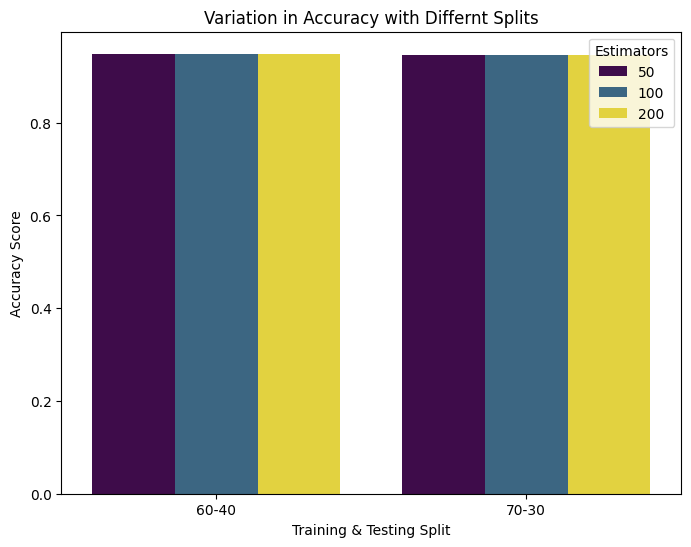

In [ ]:
# i) Variation in performance accuracy with different splits
plt.figure(figsize=(8,6))
sns.barplot(data=result, 
            x='Split', y='Accuracy', 
            hue='Estimators', 
            palette='viridis')
plt.title('Variation in Accuracy with Differnt Splits')
plt.xlabel('Training & Testing Split')
plt.ylabel('Accuracy Score')

Text(0.5, 1.0, 'Error Metrics variation with Train-Test Splits')

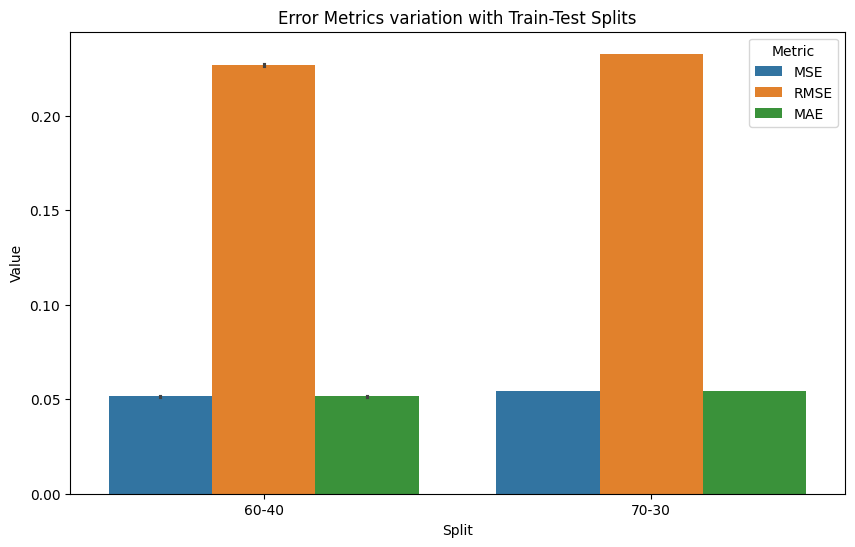

In [43]:
# ii) Variation in Error Metrics (MSE, RMSE, MAE) with Splits
metrics_melted_split = result.melt(id_vars=['Split'], value_vars=['MSE', 'RMSE', 'MAE'], 
                                       var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted_split, x='Split', y='Value', hue='Metric')
plt.title('Error Metrics variation with Train-Test Splits')

Text(0.5, 1.0, 'Error Metrics variation with Estimators and Jobs')

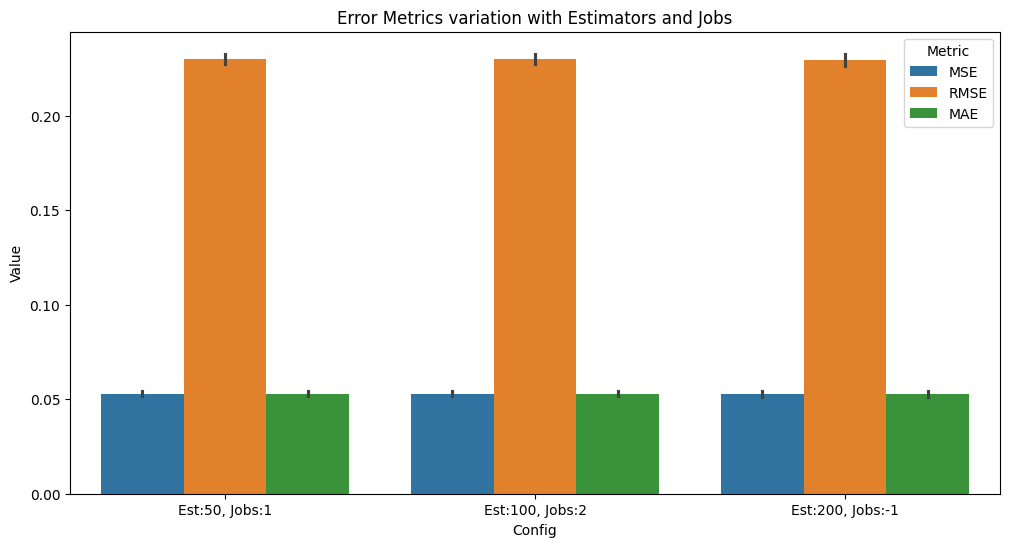

In [44]:
# iii) Variation in Error Metrics with Estimators and Jobs
metrics_melted_config = result.melt(id_vars=['Config'], value_vars=['MSE', 'RMSE', 'MAE'], 
                                        var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melted_config, x='Config', y='Value', hue='Metric')
plt.title('Error Metrics variation with Estimators and Jobs')

# Conclusion
The Random Forest model demonstrated high stability, maintaining an accuracy of approximately 94.8% across both 60-40 and 70-30 train-test splits. While increasing the number of estimators to 200 provided a marginal improvement in error metrics, the consistency of the results suggests that the model is well-generalized to the stroke prediction dataset.